In [14]:
import pandas as pd
import spacy
import textstat
import collections
import matplotlib.pyplot as plt
import seaborn as sns
import string
from nltk.tokenize import word_tokenize
import numpy as np

nlp = spacy.load("en_core_web_sm", disable=["ner"])

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [ ]:
def load_and_label(path, label, author, target_style):
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()
        paragraphs = [p.strip() for p in text.split('\n\n') if len(p.split()) > 20]
    
    return pd.DataFrame({
        'text': paragraphs,
        'label': label,         
        'author': author,       
        'target_style': target_style  
    })

# --- CONFIGURATION ---
files = [
    # Human (Class 1)
    ("../data/processed/cthulhuchunked.txt", "Human", "Lovecraft", "Lovecraft"),
    ("../data/processed/prideprejudicechunked.txt", "Human", "Austen", "Austen"),
    ("../data/processed/taleOf2Citieschunked.txt", "Human", "Dickens", "Dickens"),
    
    # Generic AI (Class 2)
    ("../data/generated/cthulhu_class2.txt", "AI_Generic", "Gemini", "Lovecraft"),
    ("../data/generated/prideprejudice_class2.txt", "AI_Generic", "Gemini", "Austen"),
    ("../data/generated/2cities_class2.txt", "AI_Generic", "Gemini", "Dickens"),

    # Imposter AI (Class 3)
    ("../data/generated/cthulhu_class3.txt", "AI_Imposter", "Gemini", "Lovecraft"),
    ("../data/generated/prideprejudice_class3.txt", "AI_Imposter", "Gemini", "Austen"),
    ("../data/generated/2cities_class3.txt", "AI_Imposter", "Gemini", "Dickens")
]

# Load and Combine
dfs = []
for path, label, author, target in files:
    try:
        df_chunk = load_and_label(path, label, author, target)
        dfs.append(df_chunk)
        print(f"Loaded {len(df_chunk)} paragraphs from {path}")
    except FileNotFoundError:
        print(f"WARNING: File not found - {path}")

df = pd.concat(dfs, ignore_index=True)
print(f"Total Dataset Size: {len(df)} paragraphs")

Loaded 73 paragraphs from ../data/processed/cthulhuchunked.txt
Loaded 785 paragraphs from ../data/processed/prideprejudicechunked.txt
Loaded 347 paragraphs from ../data/processed/taleOf2Citieschunked.txt
Loaded 500 paragraphs from ../data/generated/cthulhu_class2.txt
Loaded 500 paragraphs from ../data/generated/prideprejudice_class2.txt
Loaded 500 paragraphs from ../data/generated/2cities_class2.txt
Loaded 500 paragraphs from ../data/generated/cthulhu_class3.txt
Loaded 499 paragraphs from ../data/generated/prideprejudice_class3.txt
Loaded 502 paragraphs from ../data/generated/2cities_class3.txt
Total Dataset Size: 4206 paragraphs


In [ ]:
def analyze_syntax(text):
    doc = nlp(text)
    
    # 1. pos ratio(adj/noun)
    pos_counts = doc.count_by(spacy.attrs.POS)
    adj = pos_counts.get(spacy.symbols.ADJ, 0)
    noun = pos_counts.get(spacy.symbols.NOUN, 1) # Safety 1 to avoid ZeroDiv
    pos_ratio = adj / noun
    
    # 2. dependency tree depth
    depths = []
    for sent in doc.sents:
        roots = [token for token in sent if token.head == token]
        if not roots: continue
        
        # Recursive depth finder
        def get_depth(node):
            if not list(node.children): return 1
            return 1 + max(get_depth(child) for child in node.children)
        
        depths.append(get_depth(roots[0]))
    
    avg_depth = np.mean(depths) if depths else 0
    
    # 3. readibility
    flesch = textstat.flesch_kincaid_grade(text)
    
    return pd.Series([pos_ratio, avg_depth, flesch], 
                     index=['adj_noun_ratio', 'avg_tree_depth', 'flesch_kincaid'])

# Apply to the dataframe (This might take a minute)
print("Running SpaCy Analysis... this may take time...")
df[['adj_noun_ratio', 'avg_tree_depth', 'flesch_kincaid']] = df['text'].apply(analyze_syntax)
print("Done.")

Running SpaCy Analysis... this may take time...
Done.


In [42]:
def get_corpus_metrics(text_list, sample_size=5000):
    """
    Joins paragraphs into one giant text, takes a 5000-word slice,
    and calculates Hapax and TTR.
    """
    # Join all text and tokenize
    full_text = " ".join(text_list).lower()
    tokens = [t.text for t in nlp(full_text) if t.is_alpha]
    
    # Slice to exactly sample_size (if available)
    if len(tokens) > sample_size:
        tokens = tokens[:sample_size]
    
    # Calculations
    counts = collections.Counter(tokens)
    
    # TTR: Unique types / Total tokens
    ttr = len(counts) / len(tokens)
    
    # Hapax: Words appearing exactly once
    hapax = sum(1 for word, count in counts.items() if count == 1)
    
    return ttr, hapax

# Group by Class and Target Style to compare apples-to-apples
results = []
for (label, target), group in df.groupby(['label', 'target_style']):
    ttr, hapax = get_corpus_metrics(group['text'].tolist())
    results.append({
        'Label': label,
        'Target': target,
        'TTR': ttr,
        'Hapax_Legomena': hapax
    })

df_lexical = pd.DataFrame(results)
print(df_lexical)

         Label     Target     TTR  Hapax_Legomena
0   AI_Generic     Austen  0.1538             339
1   AI_Generic    Dickens  0.1440             318
2   AI_Generic  Lovecraft  0.1576             347
3  AI_Imposter     Austen  0.1818             456
4  AI_Imposter    Dickens  0.2748             829
5  AI_Imposter  Lovecraft  0.1942             437
6        Human     Austen  0.2810             932
7        Human    Dickens  0.2782             883
8        Human  Lovecraft  0.3526            1203


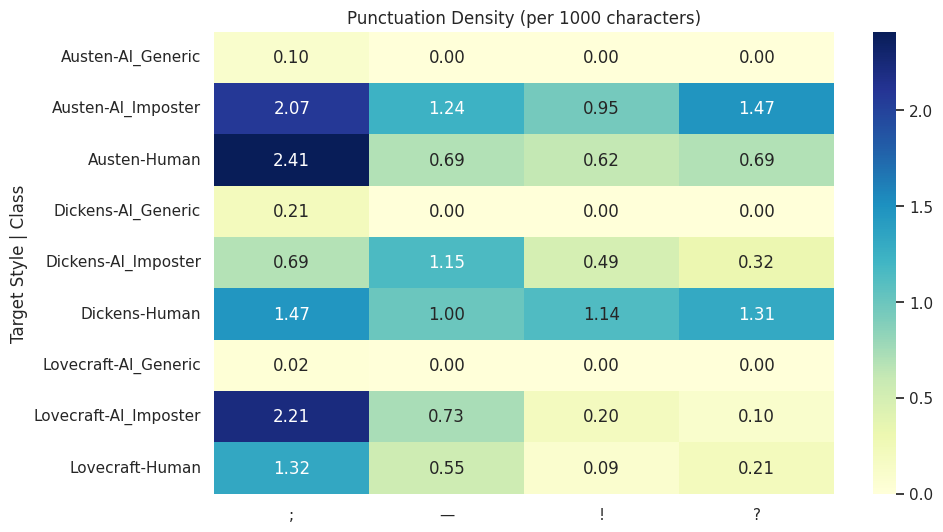

In [43]:
def count_punctuation(text):
    return {
        ';': text.count(';'),
        '—': text.count('—') + text.count('--'), # Handle both em-dash types
        '!': text.count('!'),
        '?': text.count('?')
    }

# Apply counting
punct_df = df['text'].apply(count_punctuation).apply(pd.Series)
df_punct = pd.concat([df[['label', 'target_style']], punct_df], axis=1)

# Normalize by text length (per 1000 chars) to be fair
df['char_len'] = df['text'].apply(len)
for col in [';', '—', '!', '?']:
    df_punct[col] = (df_punct[col] / df['char_len']) * 1000

# Plotting the Heatmap
plt.figure(figsize=(10, 6))
heatmap_data = df_punct.groupby(['target_style', 'label'])[[ ';', '—', '!', '?']].mean()
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Punctuation Density (per 1000 characters)")
plt.ylabel("Target Style | Class")
plt.show()

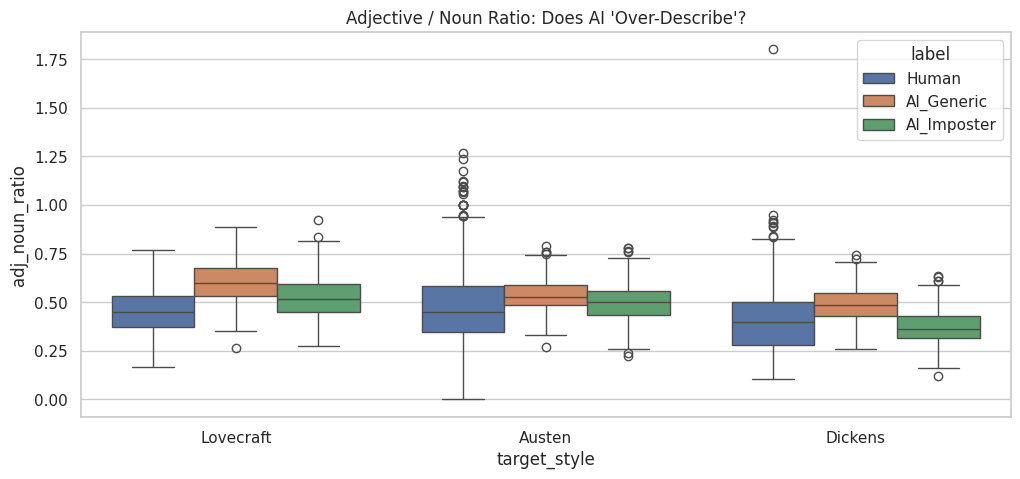

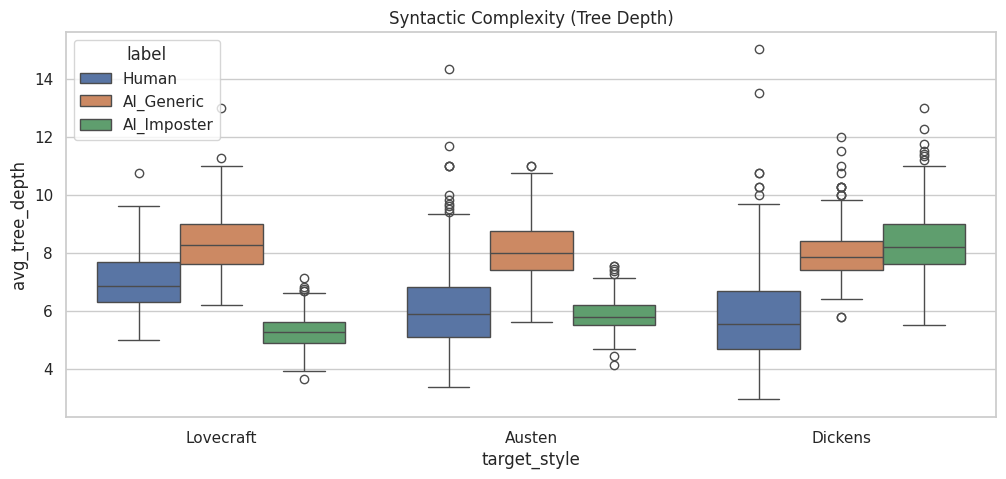

In [44]:
# 1. Adjective/Noun Ratio Plot
plt.figure(figsize=(12, 5))
sns.boxplot(x='target_style', y='adj_noun_ratio', hue='label', data=df)
plt.title("Adjective / Noun Ratio: Does AI 'Over-Describe'?")
plt.show()

# 2. Tree Depth Plot
plt.figure(figsize=(12, 5))
sns.boxplot(x='target_style', y='avg_tree_depth', hue='label', data=df)
plt.title("Syntactic Complexity (Tree Depth)")
plt.show()

Calculating Readability Scores...


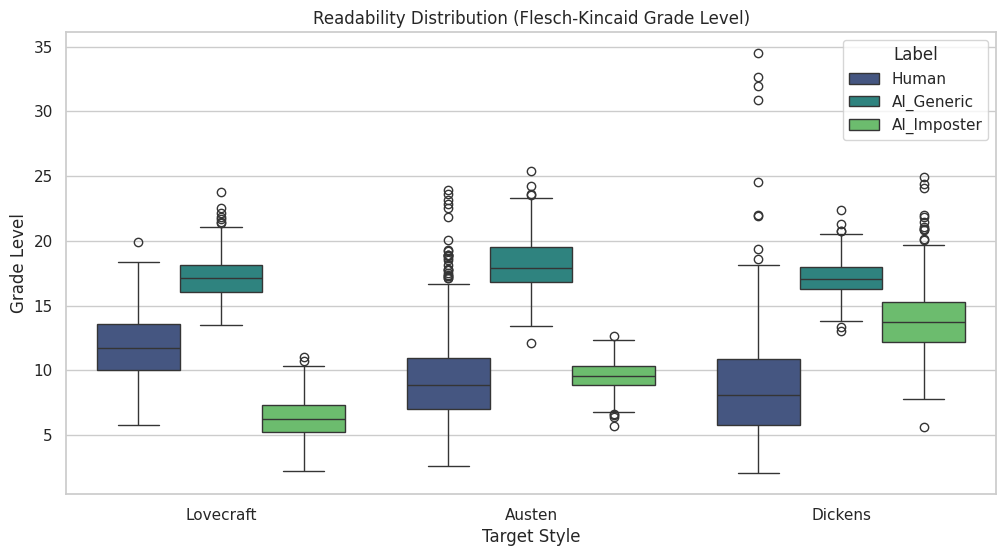

                          count       mean       std        min        25%  \
target_style label                                                           
Austen       AI_Generic   500.0  18.143971  1.962990  12.111470  16.860196   
             AI_Imposter  499.0   9.583681  1.063219   5.735779   8.886864   
             Human        785.0   9.269257  3.291342   2.617500   7.015000   
Dickens      AI_Generic   500.0  17.162296  1.351829  13.067689  16.260784   
             AI_Imposter  502.0  13.896167  2.569941   5.635758  12.152425   
             Human        347.0   8.921964  4.492666   2.055000   5.786250   
Lovecraft    AI_Generic   500.0  17.207437  1.516408  13.477598  16.063821   
             AI_Imposter  500.0   6.330747  1.504072   2.231159   5.274272   
             Human         73.0  11.850337  2.800115   5.768750   9.991786   

                                50%        75%        max  
target_style label                                         
Austen       AI_Gener

In [45]:
import textstat
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the Score
# (This runs fast)
print("Calculating Readability Scores...")
df['flesch_kincaid'] = df['text'].apply(textstat.flesch_kincaid_grade)

# 2. Visualize
plt.figure(figsize=(12, 6))
sns.boxplot(x='target_style', y='flesch_kincaid', hue='label', data=df, palette="viridis")

plt.title("Readability Distribution (Flesch-Kincaid Grade Level)")
plt.ylabel("Grade Level")
plt.xlabel("Target Style")
plt.legend(title='Label')
plt.show()

# 3. Print Summary Stats (to put in your report text)
print(df.groupby(['target_style', 'label'])['flesch_kincaid'].describe())

# Task 2

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Assume 'df' is your main dataframe from Task 1
# We need to make sure all features are per-row (per paragraph)

# 1. recalculate per paragraph TTR
def get_row_ttr(text):
    tokens = text.lower().split()
    if len(tokens) == 0: return 0
    return len(set(tokens)) / len(tokens)

df['ttr_paragraph'] = df['text'].apply(get_row_ttr)

# 2 normalize punctuation counts
df['char_len'] = df['text'].apply(len)
punct_chars = [';', '—', '!', '?', ',']
for p in punct_chars:
    col_name = f'punct_{p}'
    df[col_name] = df['text'].apply(lambda x: x.count(p)) / df['char_len'] * 1000

# 3. selecting features for x
# I'll exclude hapax per paragraph because its too noisy.
features = [
    'adj_noun_ratio', 
    'avg_tree_depth', 
    'flesch_kincaid',
    'ttr_paragraph',
    'punct_;',
      'punct_—', 
      'punct_!', 'punct_?', 'punct_,'
]

X = df[features].copy()
y = df['label'].map({'Human': 0, 'AI_Imposter': 1, 'AI_Generic': 1}) #AI vs Human

# check for NaNs
X = X.fillna(0)

print(f"Feature Matrix Shape: {X.shape}")
print(f"Target Distribution:\n{y.value_counts()}")

Feature Matrix Shape: (4206, 9)
Target Distribution:
label
1    3001
0    1205
Name: count, dtype: int64


In [ ]:
stratify_col = df['label'] + "_" + df['target_style']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=41, stratify=stratify_col
)

In [ ]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4, 
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=43
)

# train
model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

# evaluate
print("--- Tier A: The Statistician Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Human', 'AI']))

--- Tier A: The Statistician Results ---
Accuracy: 0.9762

Classification Report:
              precision    recall  f1-score   support

       Human       0.96      0.96      0.96       241
          AI       0.98      0.98      0.98       601

    accuracy                           0.98       842
   macro avg       0.97      0.97      0.97       842
weighted avg       0.98      0.98      0.98       842



/home/andaburger/miniconda3/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [15:56:43] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


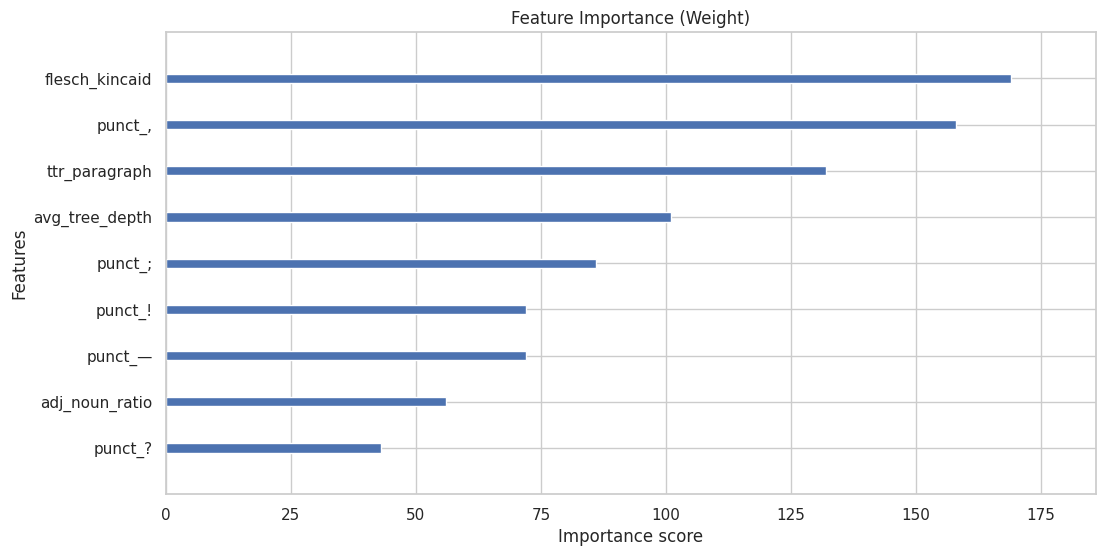

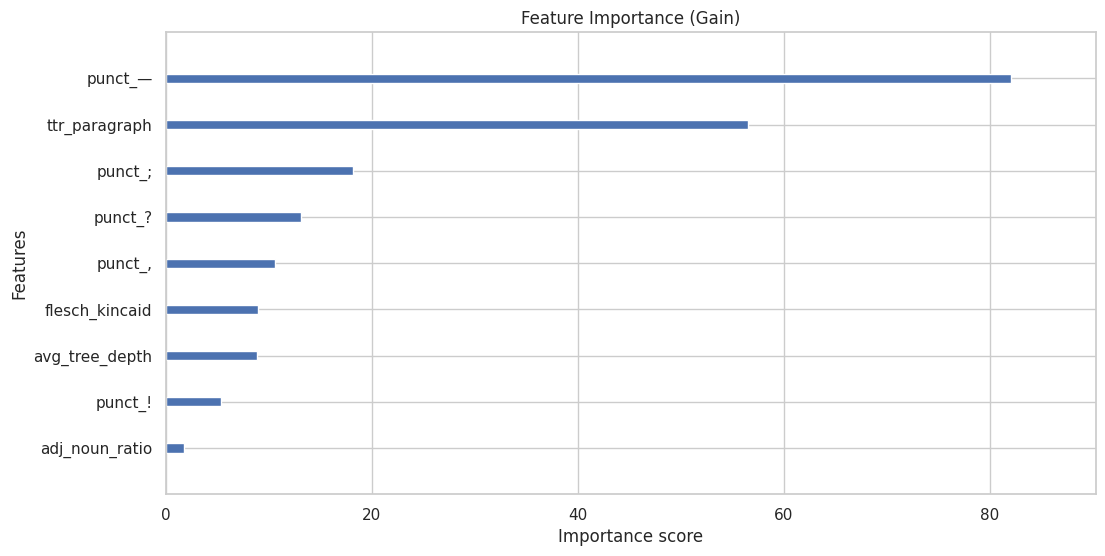

In [49]:
# Plot Feature Importance
xgb.plot_importance(model, importance_type='weight', title='Feature Importance (Weight)', show_values=False)
plt.show()

# Alternative: Gain (Contribution to accuracy) - often more accurate
xgb.plot_importance(model, importance_type='gain', title='Feature Importance (Gain)', show_values=False)
plt.show()

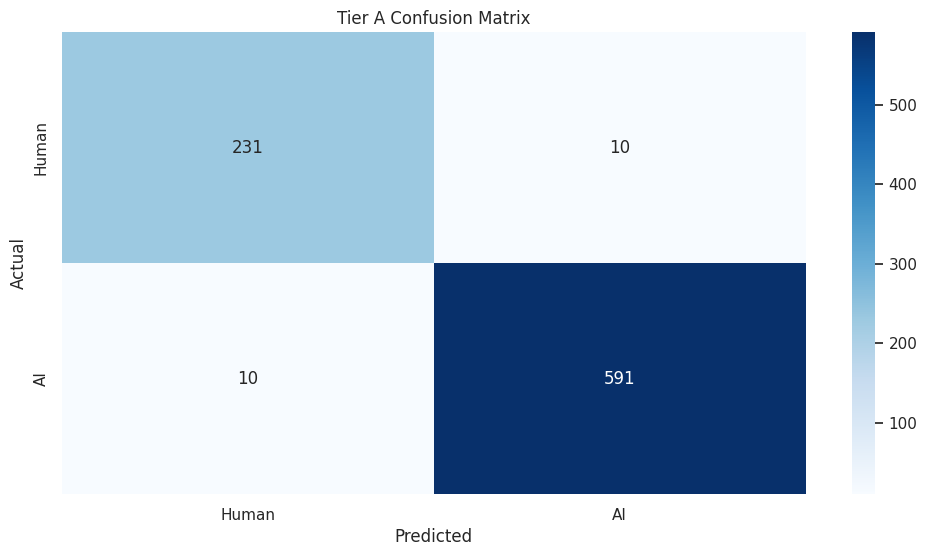

In [50]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Tier A Confusion Matrix')
plt.show()

In [52]:
# Create a dataframe of the test set with predictions
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = y_pred
test_results['text'] = df.loc[X_test.index, 'text'] # Fetch original text
test_results['author'] = df.loc[X_test.index, 'target_style']

# Find "AI that tricked the model" (False Negatives)
successful_imposters = test_results[(test_results['actual'] == 1) & (test_results['predicted'] == 0)]

print("--- AI Paragraphs that fooled The Statistician ---")
for i, row in successful_imposters.head(3).iterrows():
    print(f"\n[Author Target: {row['author']}]")
    print(f"Text: {row['text'][:2000]}...")
    print(f"Stats -> Semicolons: {row['punct_;']:.2f}, Tree Depth: {row['avg_tree_depth']:.2f}")

--- AI Paragraphs that fooled The Statistician ---

[Author Target: Austen]
Text: She had misjudged him terribly, a victim of the social biases that whispered assumptions about his impoverished background, overlooking the quiet intelligence that was his true wealth.  Their marriage, though cloaked in societal approval, was a far cry from the romantic ideal, a calculated economic strategy for her family and a convenience for him to escape a stifling inheritance.  Love, so often idealized, was a luxury they couldn't afford; convenience had become the currency of their union.  Yet, within this constrained existence, she navigated with a subtle brilliance, resisting the expected path, her every polite inquiry and carefully chosen word a form of strategic behavior designed to protect her reputation and the honor of her lineage. Her family's immense influence had steered her here, but now, facing the consequences of her initial misjudgment, a slow but undeniable moral growth began, forged in